# **Generazione dataset sintetici**

**Generazione di dataset sintetici con CT-GAN e T-VAE**

**Installation**

In [3]:
%pip install sdv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sdv (from versions: none)
ERROR: No matching distribution found for sdv


In [6]:
pip install sdv --proxy http://proxy.istat.it:8080


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ----------------------- ---------------- 8.4/14.6 MB 42.6 MB/s eta 0:00:01
   ---------------------------------------  14.4/14.6 MB 45.8 MB/s eta 0:00:01
   ---------------------------------------- 14.6/14.6 MB 26.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------- ------------- 1.3/2.0 MB 128.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 4.1 MB/s eta 0:00:00

   ----------------------------------------  0/14 [pyyaml]
   ----------------------------------------  0/14 [pyyaml]
   ----------------------------------------  0/14 [pyyaml]
   ----------------------------------------  0/14 [pyyaml]
   -- -------------------------------------  1/14 [jmespath]
   -- -------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sdv
import pandas as pd
import os
#print(sdv.version.public)

In [3]:
nome_utente = 'donatella.papa'

**Parameters**

In [20]:
synthesizer_type="TVAE" # da settare
#synthesizer_type="CTGAN" # da settare

R='Y' # da settare

if R != "N":
    PR=10 #da settare
else:
    PR=0



In [6]:
input_dir = rf"C:\Users\{nome_utente}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\Output"
output_dir = rf"C:\Users\{nome_utente}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\Output"

input_file_name = os.path.join(
    input_dir,
    f"real_data_datasetM10_TH20_R{R}_PR{PR}_4CAT_MISS_X2.csv"
)

output_file_name = os.path.join(
    output_dir,
    f"synthetic_data_datasetM10_TH20_R{R}_PR{PR}_4CAT_MISS_X2_{synthesizer_type}.csv"
)

metadata_file_name = os.path.join(
    output_dir,
    f"{synthesizer_type}_metadata_health_M10_TH20_R{R}_PR{PR}_4CAT.json"
)

modello = os.path.join(
    output_dir,
    f"{synthesizer_type}_Modello_Sintetizzatore_M10_TH20_R{R}_PR{PR}_4CAT.pkl"
)



In [33]:
print(input_file_name)

C:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\Output\real_data_datasetM10_TH20_RY_PR20_4CAT_MISS_X2.csv


In [34]:
dataset_health = pd.read_csv(input_file_name, sep=',')

In [35]:
dataset_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      10000 non-null  int64  
 1   municipality_residence  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   civil_status            10000 non-null  object 
 4   gender                  10000 non-null  object 
 5   occupation              10000 non-null  int64  
 6   physical_activity       10000 non-null  object 
 7   genetic_predisposition  10000 non-null  object 
 8   birth_year              10000 non-null  int64  
 9   birth_month             10000 non-null  int64  
 10  birth_day               10000 non-null  int64  
 11  age_norm                10000 non-null  float64
 12  activity_norm           10000 non-null  float64
 13  predisposition_norm     10000 non-null  float64
 14  score1                  10000 non-null 

In [36]:
dataset_health.shape

(10000, 22)

In [37]:
columns_to_drop = ['id', 'score1', 'score2', 'bin1', 'bin2', 'raw_class', 'age_norm', 'activity_norm', 'predisposition_norm','birth_year','birth_month','birth_day']
dataset_health = dataset_health.drop(columns=columns_to_drop)

In [38]:
dataset_health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   municipality_residence  10000 non-null  object
 1   age                     10000 non-null  int64 
 2   civil_status            10000 non-null  object
 3   gender                  10000 non-null  object
 4   occupation              10000 non-null  int64 
 5   physical_activity       10000 non-null  object
 6   genetic_predisposition  10000 non-null  object
 7   diagnosis               10000 non-null  int64 
 8   municipality_birth      10000 non-null  object
 9   birth_dayofyear         10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [39]:
dataset_health.shape

(10000, 10)

In [40]:
from sdv.metadata import Metadata

metadata_health = Metadata.detect_from_dataframe(
    data=dataset_health,
    table_name='health_metadata')

In [41]:
metadata_health

{
    "tables": {
        "health_metadata": {
            "columns": {
                "municipality_residence": {
                    "sdtype": "categorical"
                },
                "age": {
                    "sdtype": "numerical"
                },
                "civil_status": {
                    "sdtype": "categorical"
                },
                "gender": {
                    "sdtype": "categorical"
                },
                "occupation": {
                    "sdtype": "categorical"
                },
                "physical_activity": {
                    "sdtype": "categorical"
                },
                "genetic_predisposition": {
                    "sdtype": "categorical"
                },
                "diagnosis": {
                    "sdtype": "categorical"
                },
                "municipality_birth": {
                    "sdtype": "categorical"
                },
                "birth_dayofyear": {
         

In [42]:
# Se il file json di metadati esiste lo cancello
if os.path.exists(metadata_file_name):
    os.remove(metadata_file_name)

# Salvo (verrà creato un nuovo file)
metadata_health.save_to_json(metadata_file_name)

In [ ]:
'''
if synthesizer_type =="CTGAN":
  from sdv.single_table import CTGANSynthesizer

  synthesizer = CTGANSynthesizer(metadata_health)
  synthesizer.fit(dataset_health)


if synthesizer_type =="TVAE":

  from sdv.single_table import TVAESynthesizer

  synthesizer = TVAESynthesizer(metadata_health)
  synthesizer.fit(dataset_health)
'''


In [ ]:
####OK TVAE
if synthesizer_type == "CTGAN":
    from sdv.single_table import CTGANSynthesizer

    # Creazione del modello CTGAN con parametri ottimizzati
    synthesizer = CTGANSynthesizer(
        metadata=metadata_health,  # metadata già definito con tipi variabili
        epochs=1000,                # numero di epoche
                                   # Per dataset ~10K: abbastanza alto per far convergere GAN, ma non troppo da overfit
        batch_size=500,            # dimensione del batch
                                   # Batch medio stabilizza il training; batch troppo piccolo = rumore, troppo grande = lenta convergenza
        generator_dim=(256, 256),  # dimensioni rete generatore
                                   # Reti più grandi = più capacità di catturare relazioni complesse tra variabili, ma più parametri = più rischio overfitting
        discriminator_dim=(256, 256),  # dimensioni rete discriminatore
                                       # Simile al generatore, ma discriminatore leggermente potente aiuta a ridurre mode collapse
        generator_lr=1e-4,         # learning rate del generatore
                                   # Piccolo per stabilità, troppo grande = oscillazioni
        discriminator_lr=2e-4,     # learning rate del discriminatore
                                   # Di solito leggermente più alto del generatore per bilanciare training
        discriminator_steps=5,     # quante volte aggiornare il discriminatore per ogni passo del generatore
                                   # Più step = discriminatore più forte, utile quando ci sono molte categorie rare (~10K dataset)
        pac=10,                    # packed discriminator
                                   # Raggruppa 10 record insieme per giudicare “reale/sintetico” → aiuta le categorie rare
        verbose=True               # stampa i progressi del training
    )

    synthesizer.fit(dataset_health)

elif synthesizer_type == "TVAE":
    from sdv.single_table import TVAESynthesizer

    # Creazione del modello TVAE con parametri robusti
    synthesizer = TVAESynthesizer(
        metadata=metadata_health,
        epochs=1000,                # Numero di epoche simile a CTGAN, sufficiente per dataset ~10K
        batch_size=500,            # Batch medio per stabilità training
        embedding_dim=128,         # Dimensione embedding delle categorie
                                   # Più alto = cattura più informazioni, ma più complesso; 128 è un buon compromesso per ~10K record
        compress_dims=(256, 256),  # Dimensioni della rete di compressione (encoder)
                                   # Serve a comprimere le features in embedding latente; dimensioni simili a CTGAN bilanciano capacità e overfitting
        decompress_dims=(256, 256),# Dimensioni della rete di decompressione (decoder)
                                   # Deve avere capacità simile all’encoder per ricostruire bene il dataset
        loss_factor=2,             # Peso della loss discreta vs continua
                                   # Maggiore = attenzione sulle variabili categoriali, utile con molte categorie
        verbose=True               # Stampa i progressi del training
    )

    synthesizer.fit(dataset_health)

else:
    raise ValueError(f"Unsupported synthesizer_type: {synthesizer_type}")

"""
loss_factor
0.1 = Ultra-focus numeriche (code, varianza)
1.0 = Equilibrato
2.0 = Default (categoriche)
3.0+ = Forza categoriche (rischio loss alta)
"""

Loss: 2.225: 100%|██████████| 1000/1000 [2:22:00<00:00,  8.52s/it]


'\nloss_factor\n0.1 = Ultra-focus numeriche (code, varianza)\n1.0 = Equilibrato\n2.0 = Default (categoriche)\n3.0+ = Forza categoriche (rischio loss alta)\n'

In [ ]:
synthetic_data = synthesizer.sample(num_rows= 10000)
synthetic_data.head()

,municipality_residence,age,civil_status,gender,occupation,physical_activity,genetic_predisposition,diagnosis,municipality_birth,birth_dayofyear
0,Taranto,44,Married,Male,1,1.0,4.0,4,Bari,15
1,San Marzano di San Giuseppe,19,NeverMarried,Male,1,2.0,2.0,1,Montesano Salentino,350
2,Mesagne,57,NeverMarried,Female,1,3.0,5.0,2,Ugento,343
3,Torchiarolo,19,NeverMarried,Male,1,3.0,6.0,2,Novara,18
4,Leverano,41,NeverMarried,Female,1,1.0,4.0,3,Galatone,278


In [ ]:
print(modello)

/content/drive/MyDrive/WP13-PrivacyGroup/essnetFile/TVAE_num_Modello_Sintetizzatore_M10_TH20_RY_PR5_4CAT.pkl


In [ ]:
synthesizer.save(modello)

In [ ]:
print(synthesizer.get_parameters())

{'enforce_min_max_values': True, 'enforce_rounding': True, 'embedding_dim': 128, 'compress_dims': (256, 256), 'decompress_dims': (256, 256), 'l2scale': 1e-05, 'batch_size': 500, 'verbose': True, 'epochs': 1000, 'loss_factor': 2, 'enable_gpu': True}


In [ ]:
print(output_file_name)

/content/drive/MyDrive/WP13-PrivacyGroup/essnetFile/synthetic_data_datasetM10_TH20_RY_PR5_4CAT_MISS_X2_TVAE_num.csv


In [ ]:
# Export the dataframe to a CSV file with a comma separator.
synthetic_data.to_csv(output_file_name, sep=',', index=False)

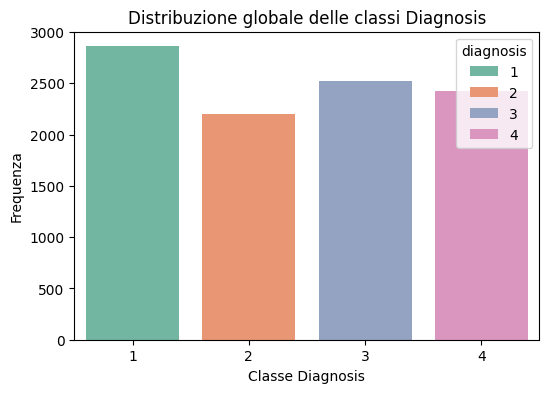

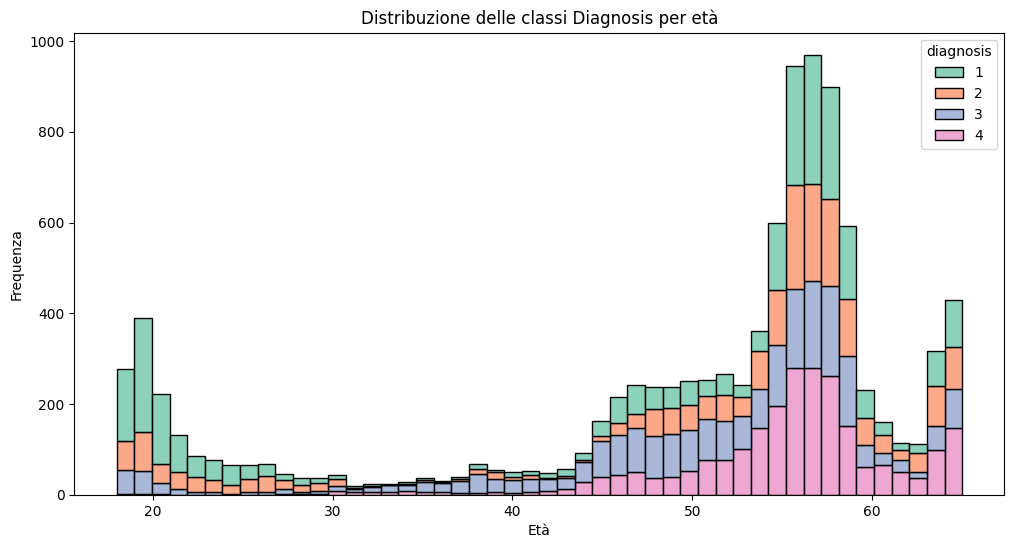

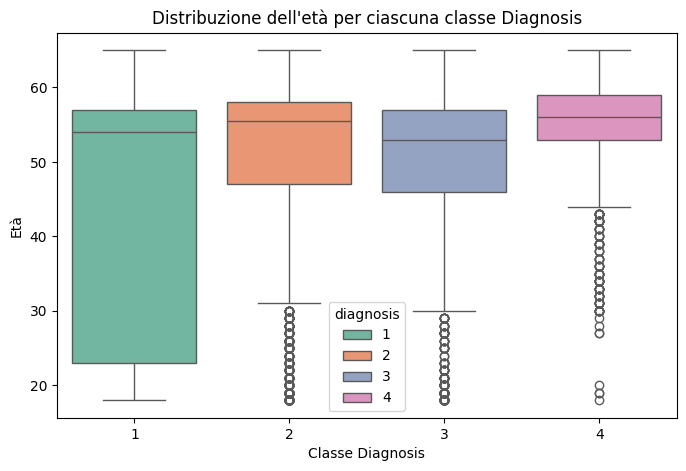

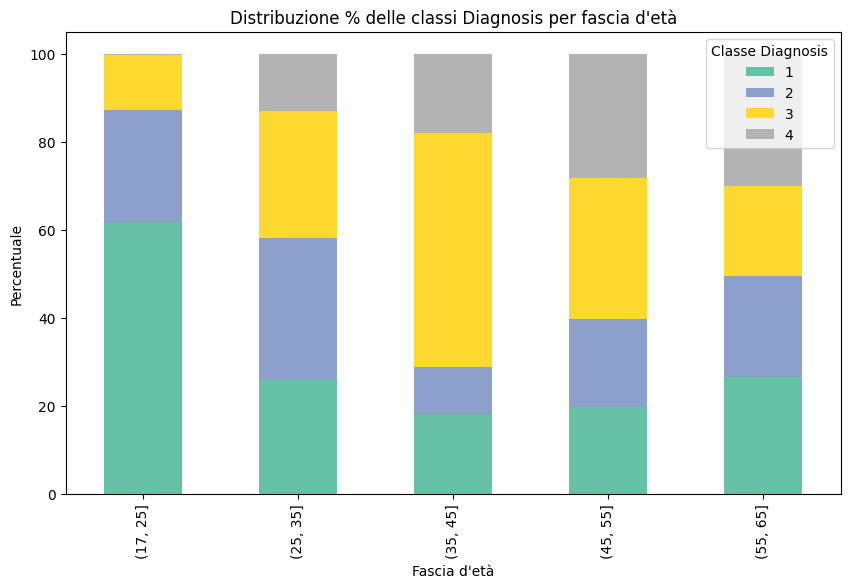

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

output_dir = rf"C:\Users\{nome_utente}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\Plot"
os.makedirs(output_dir, exist_ok=True)

# Grafico 1
plt.figure(figsize=(6,4))
sns.countplot(data=synthetic_data, x='diagnosis', hue='diagnosis', palette='Set2')
plt.title("Distribuzione globale delle classi Diagnosis")
plt.xlabel("Classe Diagnosis")
plt.ylabel("Frequenza")
plt.savefig(f"{output_dir}/grafico1_diagnosis_Syntdata_R{R}_PR{PR}_4CAT_MISS_X2_{synthesizer_type}.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# Grafico 2
plt.figure(figsize=(12,6))
sns.histplot(data=synthetic_data, x='age', hue='diagnosis', multiple='stack', palette='Set2', bins=48)
plt.title("Distribuzione delle classi Diagnosis per età")
plt.xlabel("Età")
plt.ylabel("Frequenza")
plt.savefig(f"{output_dir}/grafico2_diagnosis_age_Syntdata_R{R}_PR{PR}_4CAT_MISS_X2_{synthesizer_type}.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# Grafico 3
plt.figure(figsize=(8,5))
sns.boxplot(data=synthetic_data, x='diagnosis', y='age', hue='diagnosis', palette='Set2')
plt.title("Distribuzione dell'età per ciascuna classe Diagnosis")
plt.xlabel("Classe Diagnosis")
plt.ylabel("Età")
plt.savefig(f"{output_dir}/grafico3_boxplot_diagnosis_age_Syntdata_R{R}_PR{PR}_4CAT_MISS_X2_{synthesizer_type}.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# Grafico 4
age_bins = pd.cut(synthetic_data['age'], bins=[17,25,35,45,55,65], right=True)
grouped = synthetic_data.groupby([age_bins, 'diagnosis'], observed=True).size().unstack().fillna(0)
percentuali = grouped.div(grouped.sum(axis=1), axis=0) * 100

percentuali.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title("Distribuzione % delle classi Diagnosis per fascia d'età")
plt.xlabel("Fascia d'età")
plt.ylabel("Percentuale")
plt.legend(title='Classe Diagnosis')
plt.savefig(f"{output_dir}/grafico4_percentuale_age_diagnosis_Syntdata_R{R}_PR{PR}_4CAT_MISS_X2_{synthesizer_type}.jpeg", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#folder = r"G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\Output"
#os.listdir(folder)
#output_file_name = (
#    r"G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat"
#    r"\Step2\Output\synthetic_data_datasetM10_TH20_RY_PR10_4CAT_MISS_X2_TVAE.csv"
#)

#synthetic_data = pd.read_csv(output_file_name)
#synthetic_data

,municipality_residence,age,civil_status,gender,occupation,physical_activity,genetic_predisposition,diagnosis,municipality_birth,birth_dayofyear
0,Taranto,35,Married,Female,1,2,1,3,Francavilla Fontana,57
1,Vernole,61,Widowed,Male,1,4,5,3,San Cesario di Lecce,86
2,San Giorgio Ionico,49,Married,Male,1,2,1,3,Taranto,164
3,Cellino San Marco,59,NeverMarried,Female,1,3,3,1,Novoli,201
4,Surbo,63,Married,Female,0,3,2,1,Collepasso,166
...,...,...,...,...,...,...,...,...,...,...
9995,Ruffano,58,NeverMarried,Male,1,2,6,2,Novara,193
9996,Nardò,53,NeverMarried,Male,0,5,2,1,Matino,266
9997,Cutrofiano,20,NeverMarried,Female,0,4,3,4,Sassari,256
9998,Carovigno,38,Married,Male,0,3,6,2,San Cesario di Lecce,298


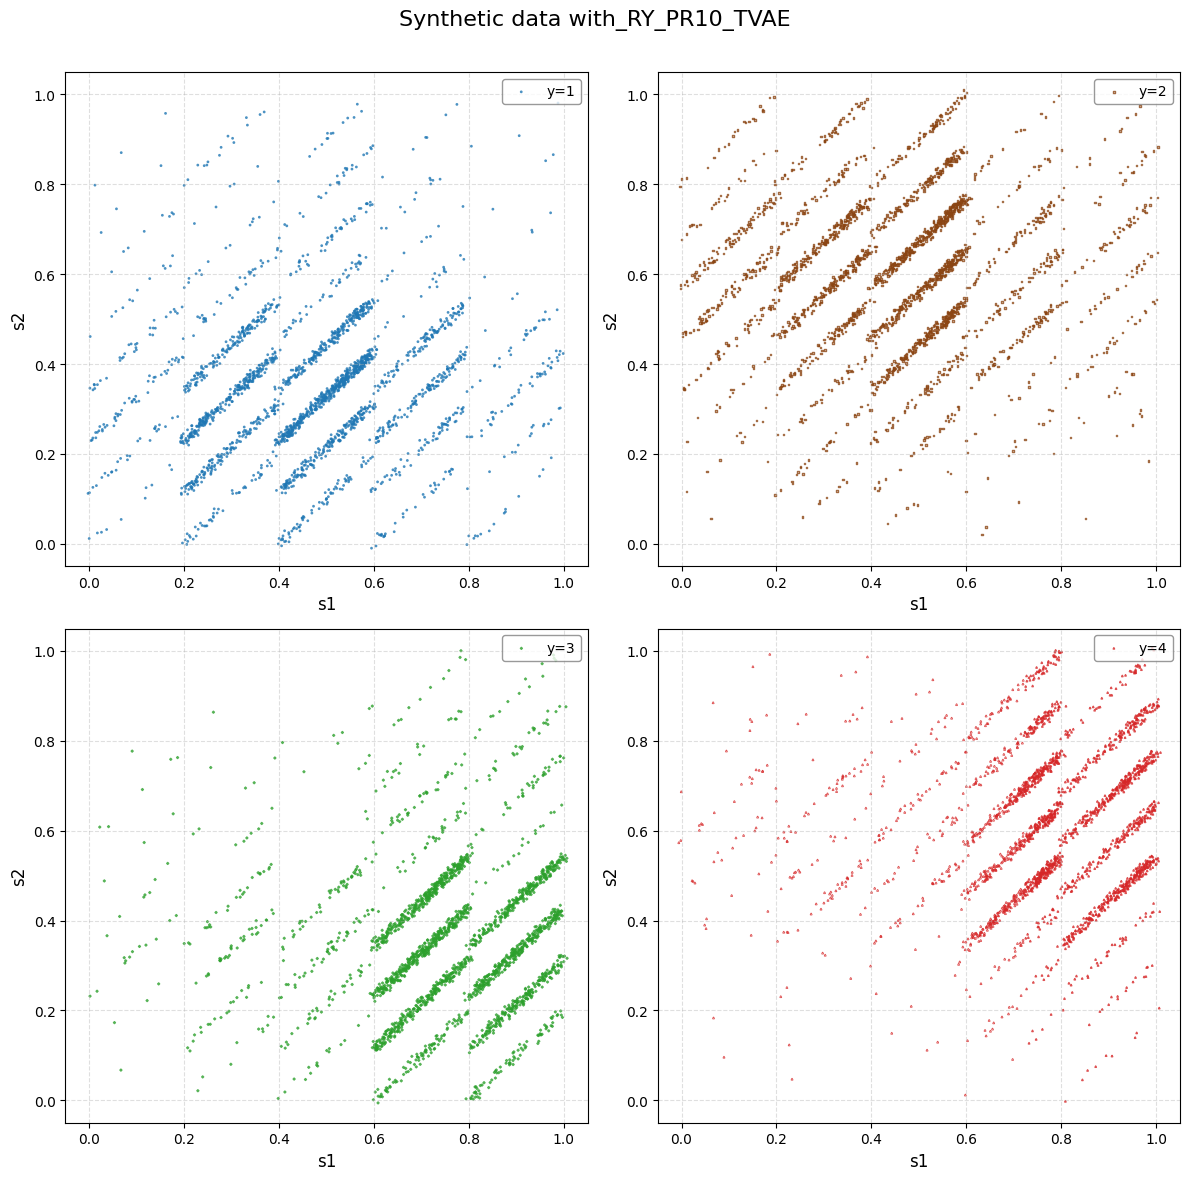

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches        # per creare la legenda
import os
from sklearn.preprocessing import MinMaxScaler


# =========================
output_dir = rf"G:\Users\{nome_utente}\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\Plot"
os.makedirs(output_dir, exist_ok=True)

# =========================
# ᐧ UNICA MODIFICA: gestione robusta missing → NaN
# =========================
missing_values = ["Missing", "missing", "NA", "N/A", ""]
synthetic_data.replace(missing_values, np.nan, inplace=True)
# =========================

scaler = MinMaxScaler()

synthetic_data['diagnosis'] = synthetic_data['diagnosis']
synthetic_data['age_norm'] = scaler.fit_transform(synthetic_data['age'].values.reshape(-1, 1))
synthetic_data['activity_norm'] = scaler.fit_transform(synthetic_data['physical_activity'].values.reshape(-1, 1))
synthetic_data['predisposition_norm'] = scaler.fit_transform(synthetic_data['genetic_predisposition'].values.reshape(-1, 1))

thresholdValue = 20

th = (thresholdValue / 100)
thcomplement = (1 - th)

# 1. Normalizza le colonne
synthetic_data['age_norm'] = scaler.fit_transform(synthetic_data['age'].values.reshape(-1, 1))
synthetic_data['activity_norm'] = scaler.fit_transform(synthetic_data['physical_activity'].values.reshape(-1, 1))
synthetic_data['predisposition_norm'] = scaler.fit_transform(synthetic_data['genetic_predisposition'].values.reshape(-1, 1))

# 2. Calcola i punteggi combinati
synthetic_data['score1'] = th * synthetic_data['age_norm'] + thcomplement * (1 - synthetic_data['activity_norm'])
synthetic_data['score2'] = th * synthetic_data['age_norm'] + thcomplement * synthetic_data['predisposition_norm']

# 2. Palette di colori personalizzata
color_map = {
    1: "#1f77b4",
    2: "#8B4513",
    3: "#2ca02c",
    4: "#d62728"
}

# 3. Marker diversi
marker_map = {
    1: "o",
    2: "s",
    3: "D",
    4: "^"
}

np.random.seed(42)

x_min = synthetic_data["score1"].min()
x_max = synthetic_data["score1"].max()
y_min = synthetic_data["score2"].min()
y_max = synthetic_data["score2"].max()

margin_x = (x_max - x_min) * 0.05
margin_y = (y_max - y_min) * 0.05
x_min -= margin_x
x_max += margin_x
y_min -= margin_y
y_max += margin_y

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, y_val in enumerate(sorted(synthetic_data["diagnosis"].unique())):
    ax = axes[i]
    subset = synthetic_data[synthetic_data["diagnosis"] == y_val]

    noise_x = np.random.uniform(-0.01, 0.01, size=len(subset))
    noise_y = np.random.uniform(-0.01, 0.01, size=len(subset))

    ax.scatter(
        subset["score1"].values + noise_x,
        subset["score2"].values + noise_y,
        label=f"y={y_val}",
        s=1,
        facecolors='none',
        edgecolors=color_map.get(y_val, "gray"),
        marker=marker_map.get(y_val, "o"),
        linewidths=1.0,
        alpha=0.8
    )

    ax.set_xlabel("s1", fontsize=12)
    ax.set_ylabel("s2", fontsize=12)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(
        loc="upper right",
        frameon=True,
        facecolor='white',
        edgecolor='gray'
    )

plt.suptitle(f"Synthetic data with_R{R}_PR{PR}_{synthesizer_type}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(f"{output_dir}/Scatterplot_Synt_data_with_R{R}_PR{PR}_{synthesizer_type}.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()